# Chromosome X Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

_, config = load_default_chrom_configs()

real_deconv2 = RealDataReplicationDeconvolution(config, replicate=2)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


###### 

In [30]:
real_deconv2.config.alpha = 0
real_deconv2.config.update_timepoints()
real_deconv2.config.calculate_H()
real_deconv2.config.params_dic

{'mu0': -20.151,
 'delta': 10.8953,
 'sigma0': 10.631,
 'sigmav': 0.1297,
 'lambda': 60.2093,
 'gamma1': 0.0017,
 'gamma2': 0.2837,
 'halted': 0.2906,
 'alpha': 20}

In [31]:
real_deconv2.setup_deconvolution(real_deconv2.config)
real_deconv2.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/339 - 00:00:00.001
100/339 - 00:00:00.025
200/339 - 00:00:00.048
300/339 - 00:00:00.071
Iteration completed 00:00:00.199, rn=0.006241213195247828


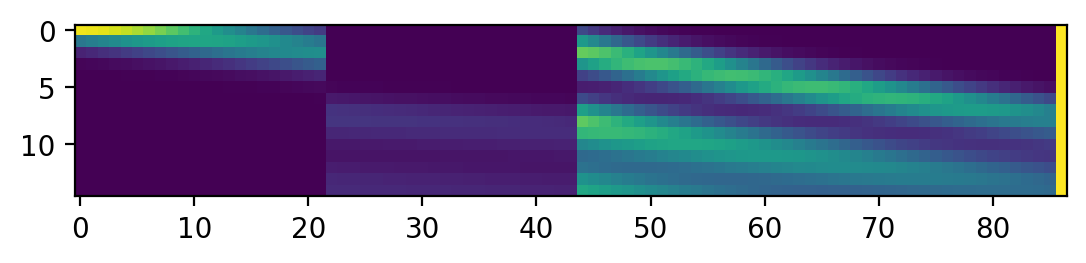

In [32]:
plt.imshow(real_deconv2.config.H, vmax=0.05)

In [33]:
from src.optimize_H import ParameterOptimizer

In [34]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-20.1510
delta,10.8953
sigma0,10.6310
sigmav,0.1297
lambda,60.2093
gamma1,0.0017
gamma2,0.2837
halted,0.2906


In [35]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (60, 80),
    'delta': (0, 14),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (0., 1.),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-20.1510,-30.00,30.0
delta,10.8953,0.00,14.0
sigma0,10.6310,1.00,14.0
sigmav,0.1297,0.01,1.0
lambda,60.2093,60.00,80.0
gamma1,0.0017,0.00,1.0
gamma2,0.2837,0.00,1.0
halted,0.2906,0.00,1.0


In [36]:
real_deconv2.setup_deconvolution(real_deconv2.config)

Initializing N using config H.
Initializing B using timepoint 0


In [37]:
real_deconv2.iterative_deconvolution_updates(20)

Iteration 0
0/339 - 00:00:00.008
100/339 - 00:00:00.032
200/339 - 00:00:00.056
300/339 - 00:00:00.080
Iteration completed 00:00:00.245, rn=0.006241213195247828
Iteration 1
0/339 - 00:00:00.246
100/339 - 00:00:00.270
200/339 - 00:00:00.293
300/339 - 00:00:00.317
Iteration completed 00:00:00.423, rn=0.0034164083022052956
Iteration 2
0/339 - 00:00:00.424
100/339 - 00:00:00.447
200/339 - 00:00:00.471
300/339 - 00:00:00.494
Iteration completed 00:00:00.800, rn=0.0031017672824662566
Iteration 3
0/339 - 00:00:00.801
100/339 - 00:00:00.825
200/339 - 00:00:00.848
300/339 - 00:00:00.871
Iteration completed 00:00:01.036, rn=0.0029362153501455786
Iteration 4
0/339 - 00:00:01.037
100/339 - 00:00:01.061
200/339 - 00:00:01.085
300/339 - 00:00:01.108
Iteration completed 00:00:01.229, rn=0.0028584360747329622
Iteration 5
0/339 - 00:00:01.230
100/339 - 00:00:01.254
200/339 - 00:00:01.277
300/339 - 00:00:01.311
Iteration completed 00:00:01.405, rn=0.0028258728152496435
Iteration 6
0/339 - 00:00:01.406
10

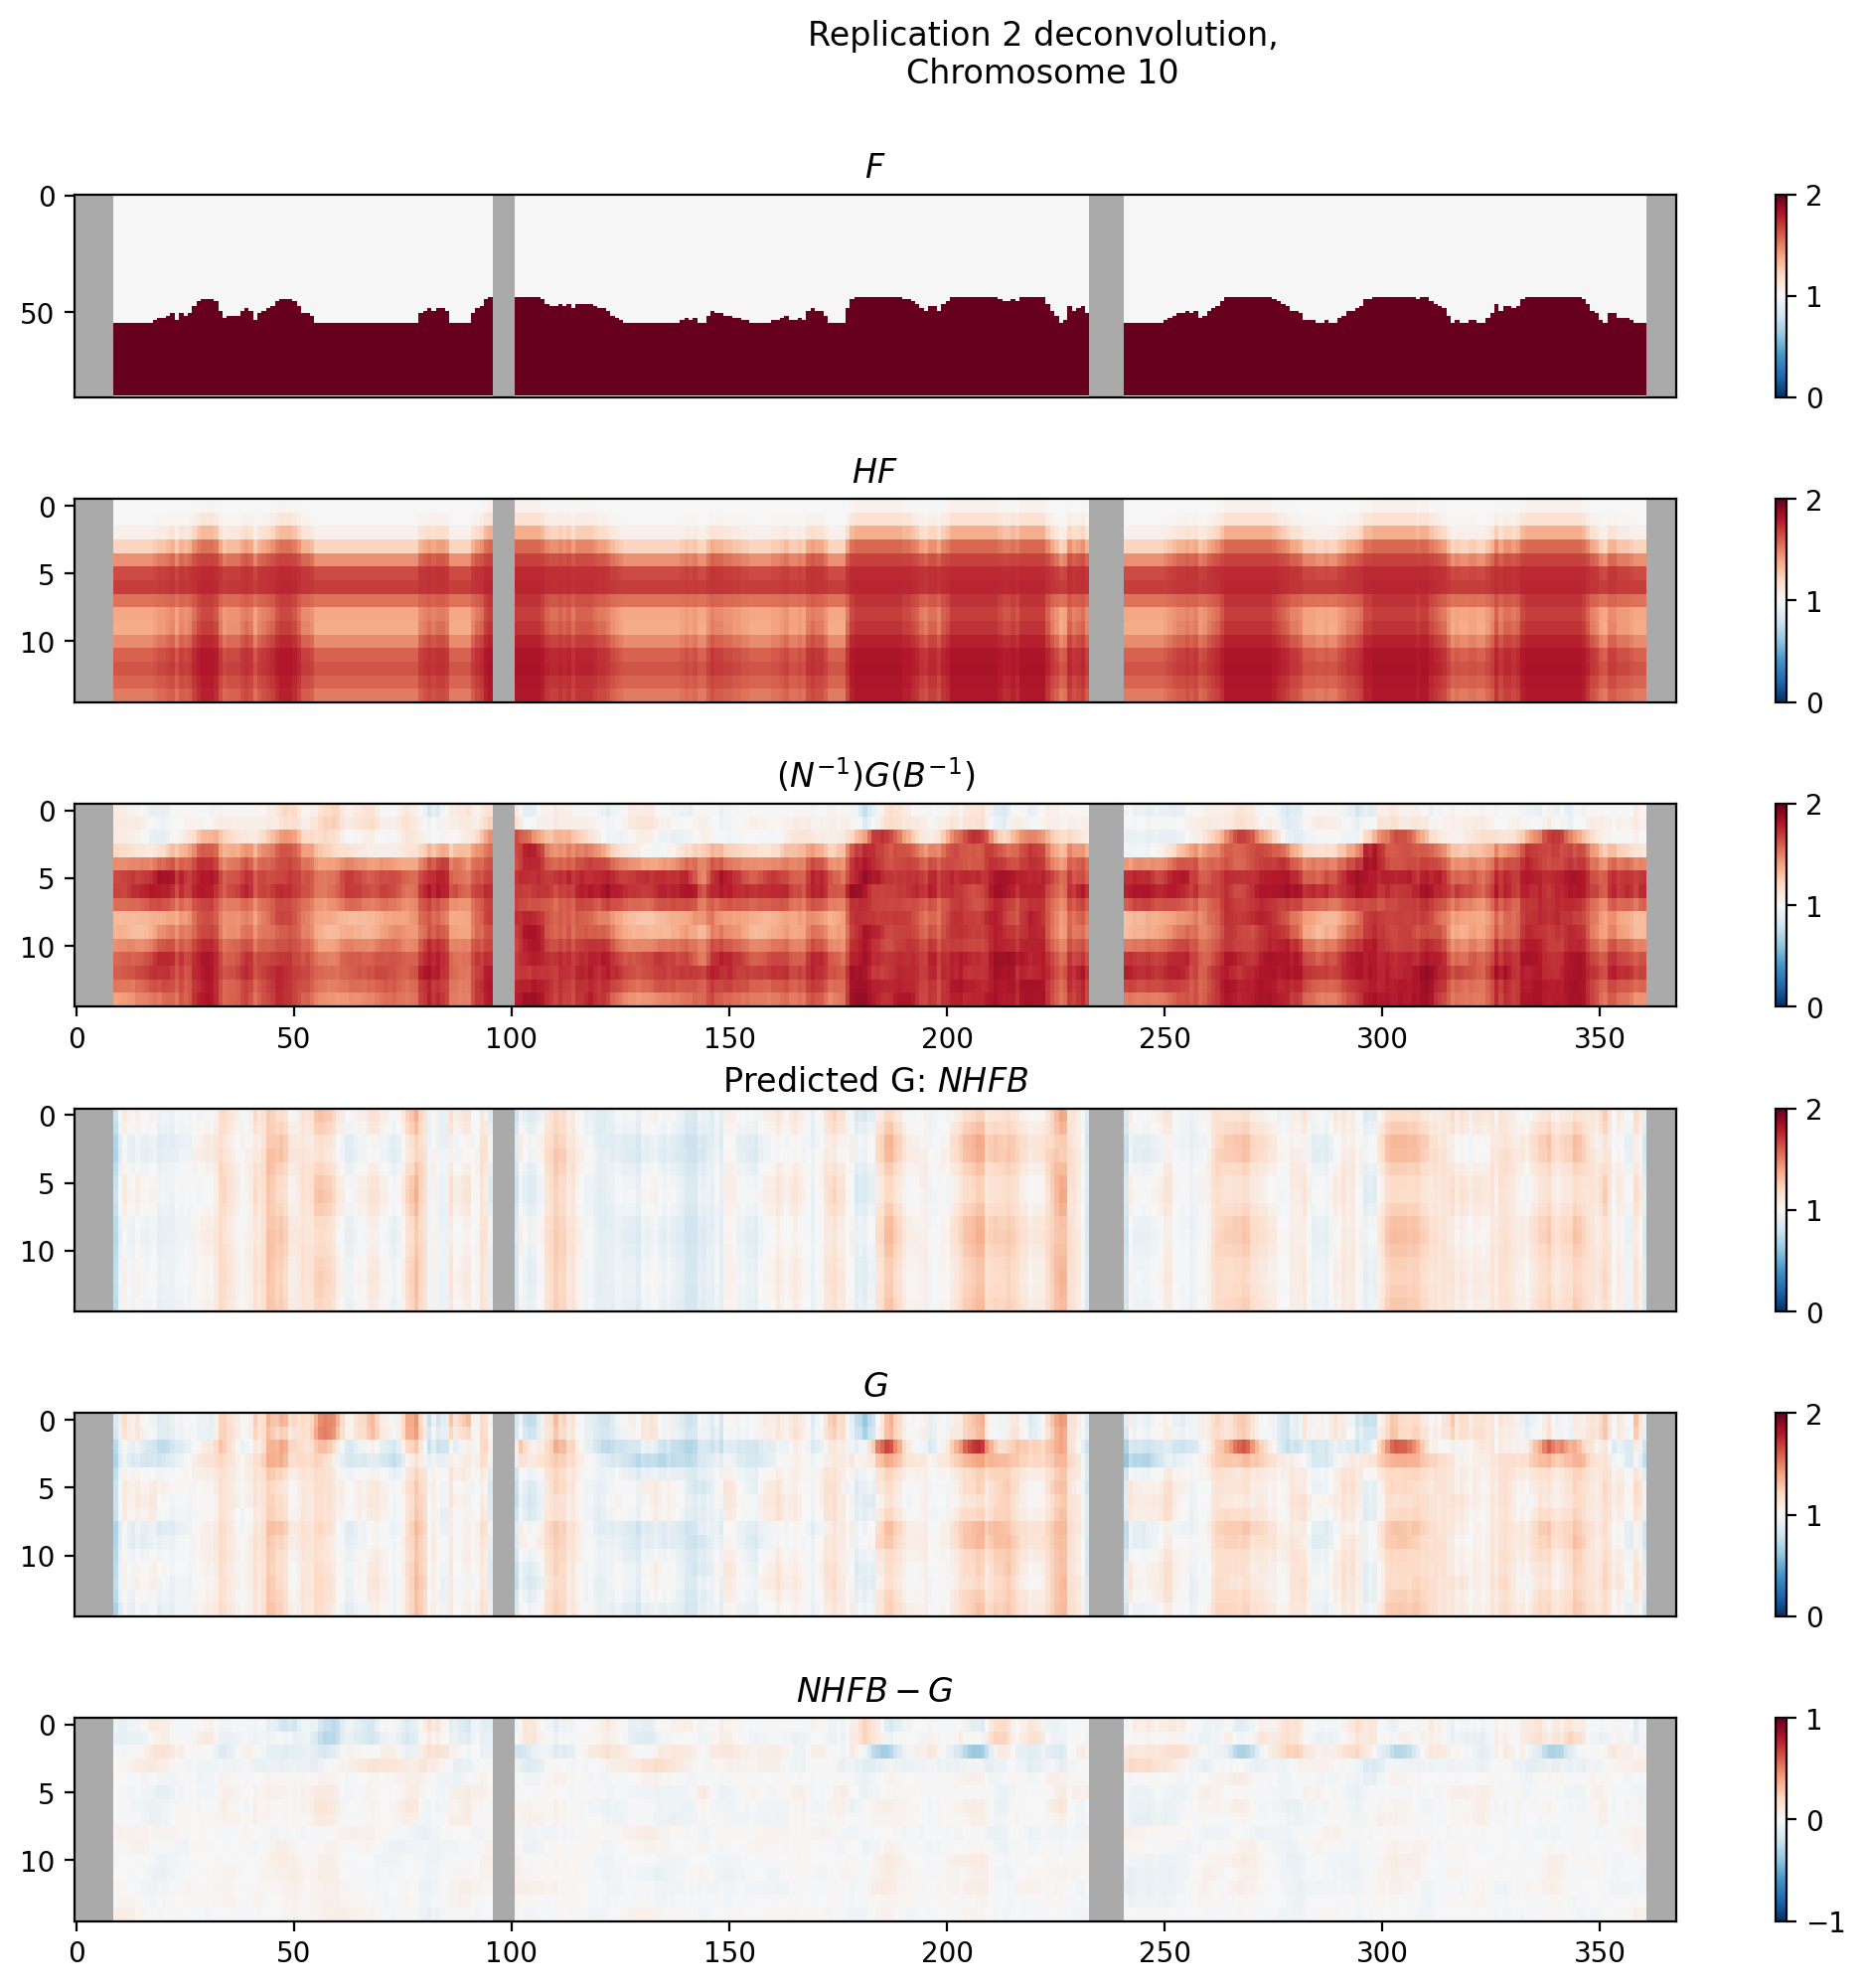

In [38]:
real_deconv2.plot_heatmaps()

In [39]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)


In [40]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 200
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv2.N
B = real_deconv2.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv2.N,
    F=real_deconv2.F,
    B=real_deconv2.B,
    G=real_deconv2.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv2.H = optimizer.current_H
        
    real_deconv2.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv2.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv2.N
    optimizer.B = real_deconv2.B
    optimizer.F = real_deconv2.F
    
    N = real_deconv2.N
    B = real_deconv2.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.0027884232290988154
Optimization [101]: Current loss: 0.002599125245530088
Optimization [201]: Current loss: 0.0025225994019100607
Optimization [301]: Current loss: 0.002519145047620228
Optimization terminated successfully.
         Current function value: 0.002519
         Iterations: 214
         Function evaluations: 333
Iteration 0
0/339 - 00:01:12.078
100/339 - 00:01:12.113
200/339 - 00:01:12.148
300/339 - 00:01:12.182
Iteration completed 00:01:12.696, rn=0.0024494981972679034
Iteration 1
0/339 - 00:01:12.698
100/339 - 00:01:12.733
200/339 - 00:01:12.770
300/339 - 00:01:12.805
Iteration completed 00:01:13.253, rn=0.0021527118404396474
Iteration 2
0/339 - 00:01:13.254
100/339 - 00:01:13.294
200/339 - 00:01:13.329
300/339 - 00:01:13.364
Iteration completed 00:01:13.815, rn=0.002111752705940569
Iteration 3
0/339 - 00:01:13.816
100/339 - 00:01:13.850
200/339 - 00:01:13.885
300/339 - 00:01:13.919
Iteration completed 00:01:14.253, rn=0.0021016

Optimization [1]: Current loss: 0.0018969297109747338
Optimization [101]: Current loss: 0.0018957301445443
Optimization [201]: Current loss: 0.0018956781973704458
Optimization [301]: Current loss: 0.0018939149840294515
Optimization [401]: Current loss: inf
Optimization [501]: Current loss: 0.001888344797963271
Optimization [601]: Current loss: 0.001888338962133367
Optimization terminated successfully.
         Current function value: 0.001888
         Iterations: 445
         Function evaluations: 686
Iteration 0
0/339 - 00:07:57.253
100/339 - 00:07:57.260
200/339 - 00:07:57.267
300/339 - 00:07:57.274
Iteration completed 00:07:57.363, rn=0.015682289553409424
Iteration 1
0/339 - 00:07:57.364
100/339 - 00:07:57.371
200/339 - 00:07:57.378
300/339 - 00:07:57.384
Iteration completed 00:07:57.483, rn=0.003849900721808379
Iteration 2
0/339 - 00:07:57.484
100/339 - 00:07:57.492
200/339 - 00:07:57.498
300/339 - 00:07:57.505
Iteration completed 00:07:57.574, rn=0.003807570554817495
Iteration 3
0

100/339 - 00:13:13.919
200/339 - 00:13:13.934
300/339 - 00:13:13.948
Iteration completed 00:13:14.320, rn=0.0027036168940740126
00:13:14.321
mu0          -11.642550
lambda        76.160173
delta          0.007371
sigma0         1.000100
sigmav         0.206156
gamma1         0.077281
gamma2         0.201479
halted         0.288707
opt_H_loss     0.002721
F_rn           0.002704
Name: 11, dtype: float64
Epoch:  12
Optimization [1]: Current loss: 0.002703616894074012
Optimization [101]: Current loss: 0.0026953904198474864
Optimization [201]: Current loss: 0.002695002195386496
Optimization terminated successfully.
         Current function value: 0.002695
         Iterations: 159
         Function evaluations: 253
Iteration 0
0/339 - 00:14:10.466
100/339 - 00:14:10.479
200/339 - 00:14:10.491
300/339 - 00:14:10.504
Iteration completed 00:14:10.703, rn=0.0026949993879646856
Iteration 1
0/339 - 00:14:10.705
100/339 - 00:14:10.724
200/339 - 00:14:10.737
300/339 - 00:14:10.751
Iteration comple

100/339 - 00:18:22.751
200/339 - 00:18:22.767
300/339 - 00:18:22.783
Iteration completed 00:18:23.410, rn=0.002295945274623253
00:18:23.410
mu0          -12.066643
lambda        76.432079
delta          0.008994
sigma0         1.000000
sigmav         0.200805
gamma1         0.085122
gamma2         0.257408
halted         0.253110
opt_H_loss     0.002321
F_rn           0.002296
Name: 17, dtype: float64
Epoch:  18
Optimization [1]: Current loss: 0.0022959452746232536
Optimization [101]: Current loss: 0.0022924276182427388
Optimization terminated successfully.
         Current function value: 0.002292
         Iterations: 117
         Function evaluations: 186
Iteration 0
0/339 - 00:19:03.125
100/339 - 00:19:03.142
200/339 - 00:19:03.161
300/339 - 00:19:03.180
Iteration completed 00:19:03.435, rn=0.0022503023113433687
Iteration 1
0/339 - 00:19:03.437
100/339 - 00:19:03.456
200/339 - 00:19:03.474
300/339 - 00:19:03.493
Iteration completed 00:19:03.840, rn=0.0022156853070845273
Iteration 2


100/339 - 00:23:16.392
200/339 - 00:23:16.417
300/339 - 00:23:16.442
Iteration completed 00:23:16.944, rn=0.0020714851518110543
00:23:16.944
mu0          -12.846025
lambda        72.407984
delta          0.012918
sigma0         1.000015
sigmav         0.190126
gamma1         0.082063
gamma2         0.349744
halted         0.250429
opt_H_loss     0.002082
F_rn           0.002071
Name: 23, dtype: float64
Epoch:  24
Optimization [1]: Current loss: 0.0020714851518110547
Optimization [101]: Current loss: 0.002069218553280725
Optimization terminated successfully.
         Current function value: 0.002069
         Iterations: 99
         Function evaluations: 168
Iteration 0
0/339 - 00:23:53.805
100/339 - 00:23:53.833
200/339 - 00:23:53.861
300/339 - 00:23:53.888
Iteration completed 00:23:54.477, rn=0.0020686697657884023
Iteration 1
0/339 - 00:23:54.478
100/339 - 00:23:54.505
200/339 - 00:23:54.532
300/339 - 00:23:54.559
Iteration completed 00:23:54.894, rn=0.0020597210822298115
Iteration 2
0

...

100/339 - 01:49:53.754
200/339 - 01:49:53.887
300/339 - 01:49:53.968
Iteration completed 01:49:54.265, rn=0.001971957139179692
Iteration 1
0/339 - 01:49:54.266
100/339 - 01:49:54.346
200/339 - 01:49:54.424
300/339 - 01:49:54.503
Iteration completed 01:49:54.948, rn=0.0019722337704938275
Iteration 2
0/339 - 01:49:54.950
100/339 - 01:49:55.028
200/339 - 01:49:55.106
300/339 - 01:49:55.184
Iteration completed 01:49:55.803, rn=0.0019722342582487577
Iteration 3
0/339 - 01:49:55.804
100/339 - 01:49:55.886
200/339 - 01:49:55.968
300/339 - 01:49:56.049
Iteration completed 01:49:56.602, rn=0.0019722342583023064
Iteration 4
0/339 - 01:49:56.603
100/339 - 01:49:56.704
200/339 - 01:49:56.798
300/339 - 01:49:56.878
Iteration completed 01:49:57.135, rn=0.0019722342583023095
01:49:57.135
mu0           -9.099120
lambda        67.341679
delta          0.488556
sigma0         1.000000
sigmav         0.179922
gamma1         0.154349
gamma2         1.000000
halted         0.107901
opt_H_loss     0.001972


100/339 - 01:53:11.458
200/339 - 01:53:11.536
300/339 - 01:53:11.613
Iteration completed 01:53:11.837, rn=0.001968538454258277
Iteration 2
0/339 - 01:53:11.838
100/339 - 01:53:11.915
200/339 - 01:53:11.993
300/339 - 01:53:12.071
Iteration completed 01:53:12.122, rn=0.0019678449330146606
Iteration 3
0/339 - 01:53:12.123
100/339 - 01:53:12.201
200/339 - 01:53:12.278
300/339 - 01:53:12.356
Iteration completed 01:53:12.462, rn=0.0019678384889169147
Iteration 4
0/339 - 01:53:12.463
100/339 - 01:53:12.541
200/339 - 01:53:12.618
300/339 - 01:53:12.695
Iteration completed 01:53:12.744, rn=0.001967838489312578
01:53:12.745
mu0           -9.035508
lambda        67.154340
delta          0.792325
sigma0         1.000077
sigmav         0.180301
gamma1         0.156148
gamma2         1.000000
halted         0.102487
opt_H_loss     0.001969
F_rn           0.001968
Name: 177, dtype: float64
Epoch:  178
Optimization [1]: Current loss: 0.001967838489312578
Optimization [101]: Current loss: 0.00196774767

100/339 - 01:56:21.324
200/339 - 01:56:21.402
300/339 - 01:56:21.480
Iteration completed 01:56:21.533, rn=0.001968776617652684
Iteration 3
0/339 - 01:56:21.534
100/339 - 01:56:21.611
200/339 - 01:56:21.688
300/339 - 01:56:21.764
Iteration completed 01:56:21.818, rn=0.0019687766177323234
Iteration 4
0/339 - 01:56:21.819
100/339 - 01:56:21.895
200/339 - 01:56:21.972
300/339 - 01:56:22.049
Iteration completed 01:56:22.164, rn=0.0019687766177323295
01:56:22.164
mu0           -8.983115
lambda        66.972877
delta          1.068183
sigma0         1.000202
sigmav         0.180722
gamma1         0.157736
gamma2         1.000000
halted         0.098148
opt_H_loss     0.001968
F_rn           0.001969
Name: 183, dtype: float64
Epoch:  184
Optimization [1]: Current loss: 0.00196877661773233
Optimization [101]: Current loss: 0.0019686912524111777
Optimization terminated successfully.
         Current function value: 0.001969
         Iterations: 82
         Function evaluations: 139
Iteration 0
0

100/339 - 01:59:47.195
200/339 - 01:59:47.272
300/339 - 01:59:47.350
Iteration completed 01:59:47.458, rn=0.0019670759111348095
Iteration 4
0/339 - 01:59:47.459
100/339 - 01:59:47.536
200/339 - 01:59:47.614
300/339 - 01:59:47.692
Iteration completed 01:59:47.774, rn=0.0019670759111348134
01:59:47.774
mu0           -8.974843
lambda        66.729458
delta          1.427005
sigma0         1.000225
sigmav         0.180904
gamma1         0.158871
gamma2         1.000000
halted         0.092901
opt_H_loss     0.001967
F_rn           0.001967
Name: 189, dtype: float64
Epoch:  190
Optimization [1]: Current loss: 0.001967075911134813
Optimization [101]: Current loss: 0.0019669764587481094
Optimization terminated successfully.
         Current function value: 0.001967
         Iterations: 80
         Function evaluations: 138
Iteration 0
0/339 - 02:00:17.882
100/339 - 02:00:17.962
200/339 - 02:00:18.041
300/339 - 02:00:18.119
Iteration completed 02:00:18.227, rn=0.001966969103719979
Iteration 1


300/339 - 02:05:09.566
Iteration completed 02:05:09.625, rn=0.0019636910602034933
Iteration 3
0/339 - 02:05:09.626
100/339 - 02:05:09.703
200/339 - 02:05:09.780
300/339 - 02:05:09.856
Iteration completed 02:05:09.946, rn=0.001963691060281078
Iteration 4
0/339 - 02:05:09.947
100/339 - 02:05:10.025
200/339 - 02:05:10.103
300/339 - 02:05:10.181
Iteration completed 02:05:10.291, rn=0.001963691060281085
02:05:10.291
mu0           -8.061430
lambda        67.387037
delta          0.030557
sigma0         1.000657
sigmav         0.181589
gamma1         0.171095
gamma2         1.000000
halted         0.087935
opt_H_loss     0.001963
F_rn           0.001964
Name: 195, dtype: float64
Epoch:  196
Optimization [1]: Current loss: 0.001963691060281085
Optimization [101]: Current loss: 0.001963624619290065
Optimization terminated successfully.
         Current function value: 0.001964
         Iterations: 93
         Function evaluations: 152
Iteration 0
0/339 - 02:05:43.312
100/339 - 02:05:43.390
200/

In [41]:
config.params_dic#get_Hpositions_for_phase('S')

{'mu0': -7.943115851947244,
 'delta': 0.031319454074731676,
 'sigma0': 1.0,
 'sigmav': 0.1818174796461659,
 'lambda': 67.34606358774437,
 'gamma1': 0.17299768312934816,
 'gamma2': 1.0,
 'halted': 0.08540779867609488,
 'alpha': 20}

Text(0.5, 0.98, 'Cell cycle parameter updates, 200 epochs')

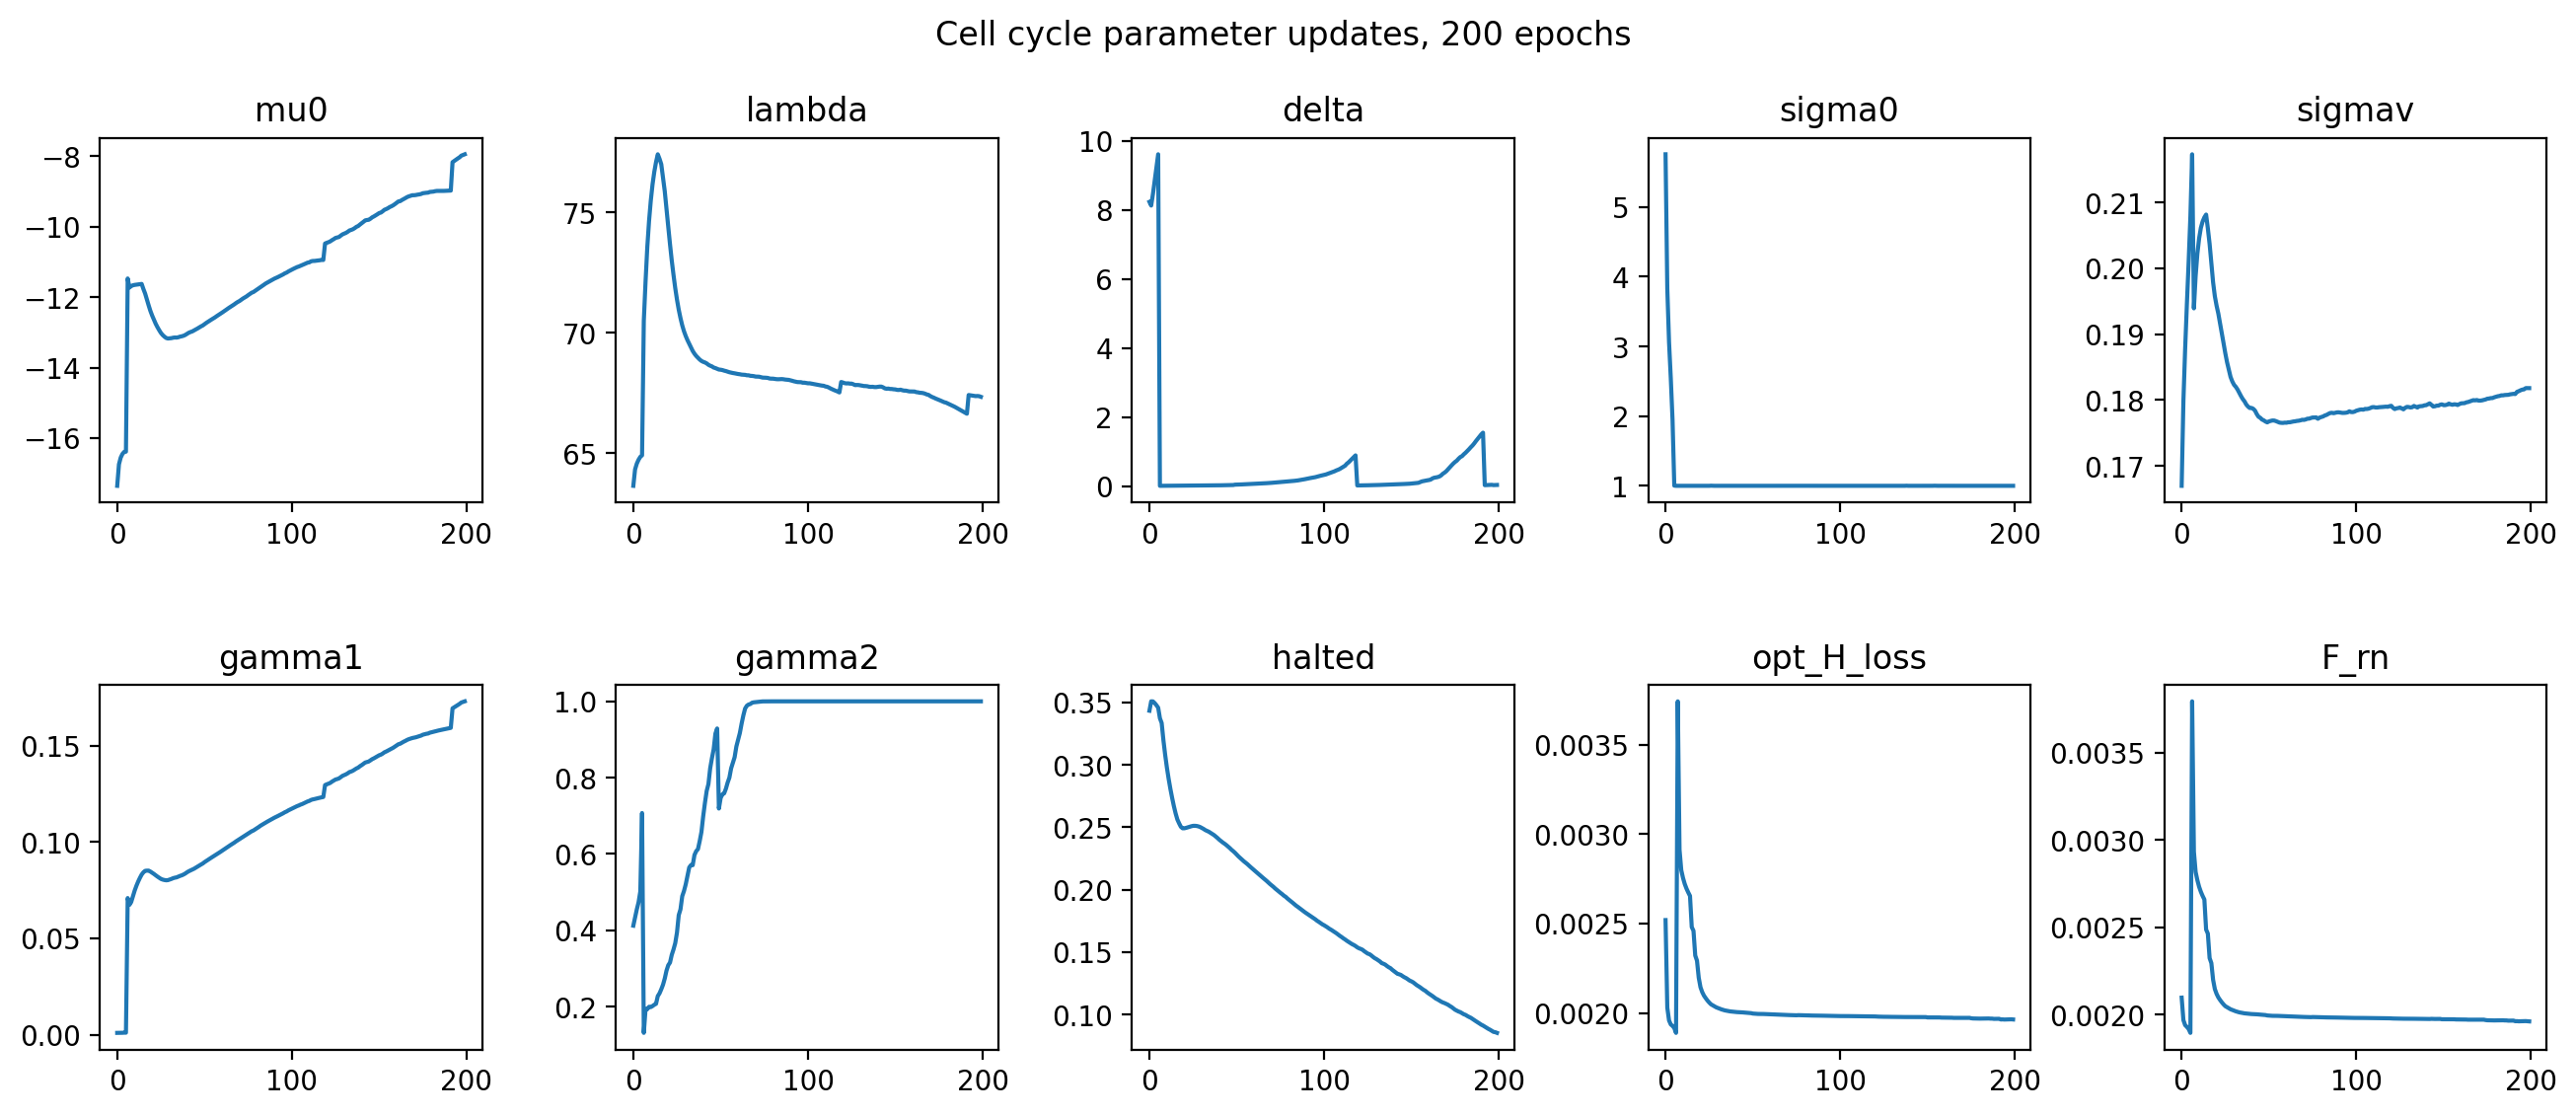

In [42]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

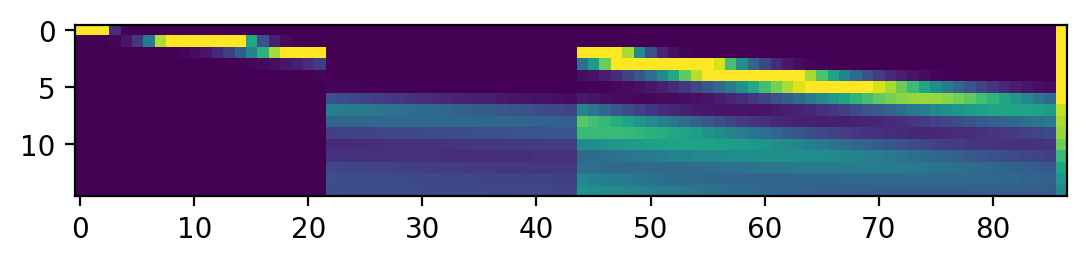

In [43]:
plt.imshow(real_deconv2.H, vmax=0.05)

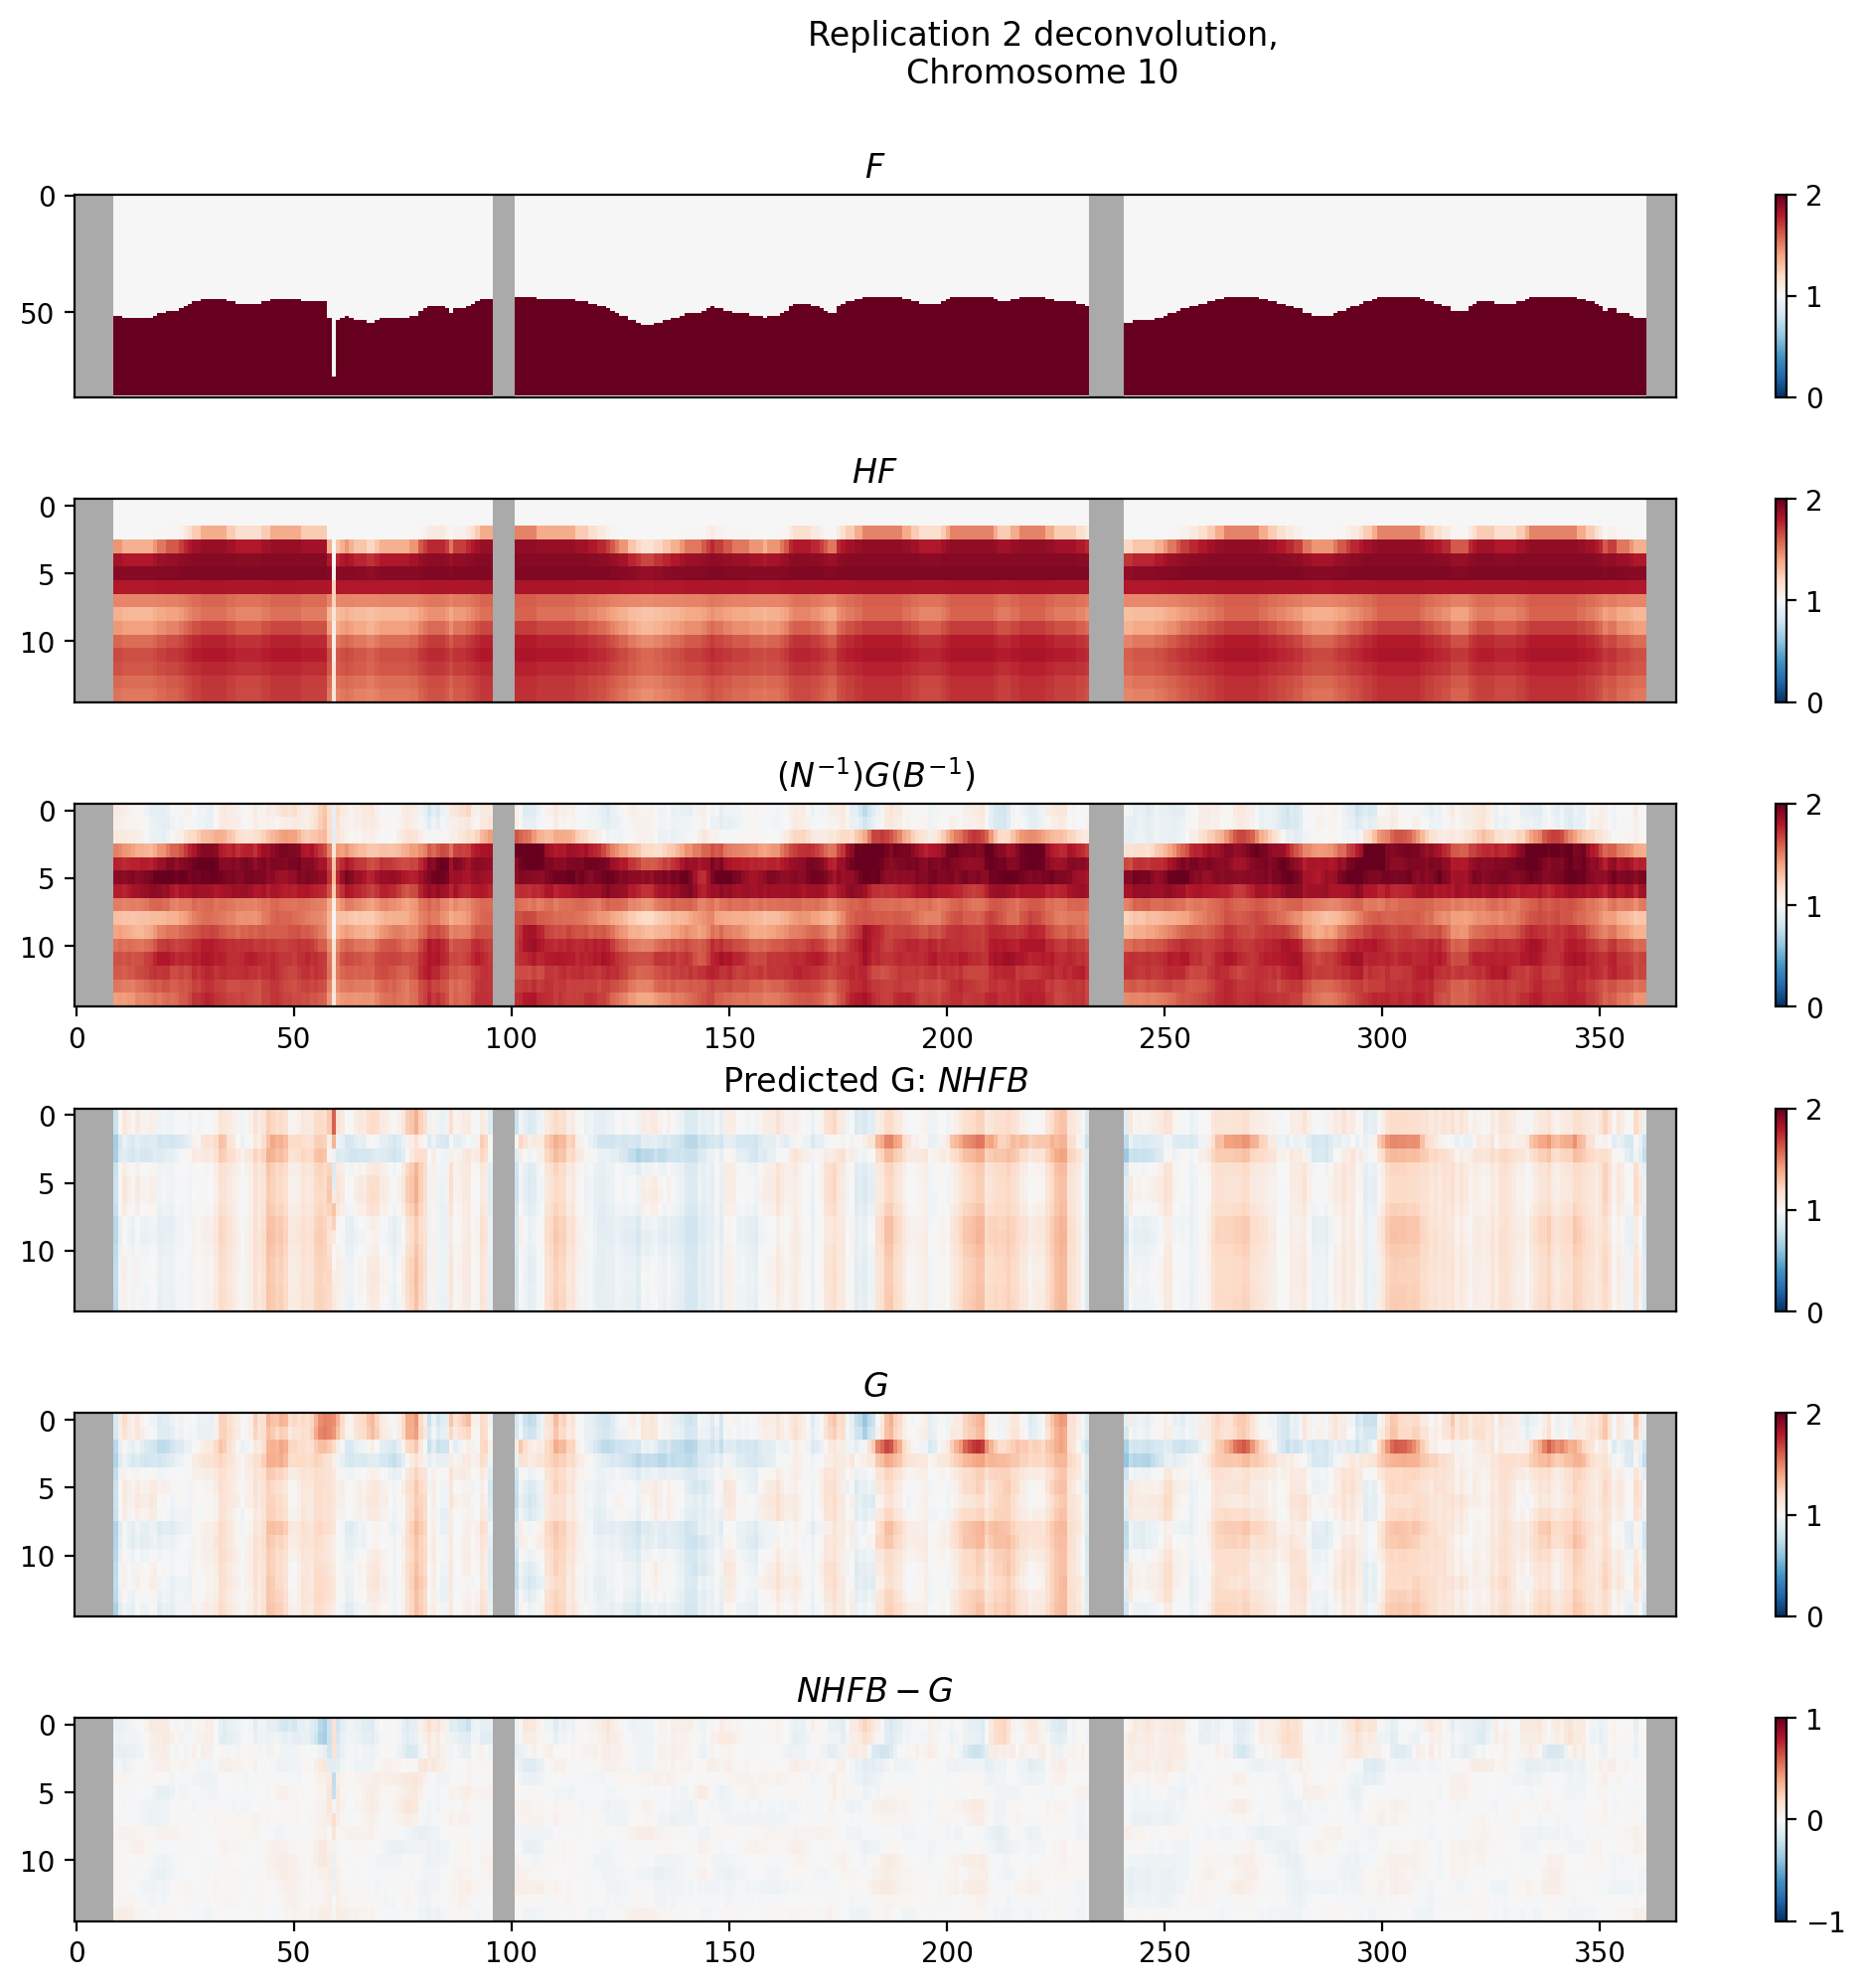

In [44]:
real_deconv2.plot_heatmaps()

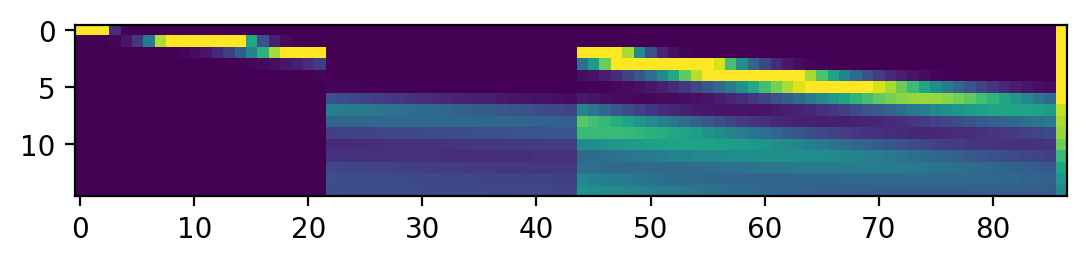

In [47]:
plt.imshow(config.H, vmax=0.05)

In [48]:
config.params_dic

{'mu0': -7.943115851947244,
 'delta': 0.031319454074731676,
 'sigma0': 1.0,
 'sigmav': 0.1818174796461659,
 'lambda': 67.34606358774437,
 'gamma1': 0.17299768312934816,
 'gamma2': 1.0,
 'halted': 0.08540779867609488,
 'alpha': 20}